In [ ]:
import sys

!{sys.executable} -m pip install pandas matplotlib seaborn openpyxl

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('owid-co2-data.csv')
df.head()


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print(df.shape)
print(df.columns.tolist())

(50411, 79)
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_p

In [8]:
denmark = df[df["country"] == "Denmark"].copy()
print(denmark.shape)

(182, 79)


In [10]:
cols = [
    'year',
    'co2',
    'co2_per_capita',
    'coal_co2',
    'oil_co2',
    'gas_co2',
    'cement_co2',
    'land_use_change_co2'
]

denmark = denmark[cols]
denmark.head()

,year,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2,land_use_change_co2
12407,1843,0.136,0.097,0.136,0.0,0.0,NaN,NaN
12408,1844,0.158,0.112,0.158,0.0,0.0,NaN,NaN
12409,1845,0.209,0.146,0.209,0.0,0.0,NaN,NaN
12410,1846,0.227,0.158,0.227,0.0,0.0,NaN,NaN
12411,1847,0.172,0.118,0.172,0.0,0.0,NaN,NaN


In [12]:
denmark.isnull().sum()

year                    0
co2                     0
co2_per_capita          0
coal_co2                0
oil_co2                 0
gas_co2                32
cement_co2             85
land_use_change_co2     7
dtype: int64

In [14]:
denmark = denmark[denmark["year"] >= 1950].reset_index(drop=True)
print(f"Years covered: {denmark['year'].min()} – {denmark['year'].max()}")
print(f"Rows: {len(denmark)}")
denmark.head()
denmark.isnull().sum()

Years covered: 1950 – 2024
Rows: 75


year                    0
co2                     0
co2_per_capita          0
coal_co2                0
oil_co2                 0
gas_co2                32
cement_co2              0
land_use_change_co2     0
dtype: int64

In [15]:
denmark.describe()

,year,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2,land_use_change_co2
count,75.000000,75.000000,75.000000,75.000000,75.000000,43.000000,75.000000,75.000000
mean,1987.000000,47.014760,9.138280,15.844320,25.830520,6.707256,1.016840,2.330240
std,21.794495,13.891495,2.640745,7.415282,11.529364,3.413443,0.273333,3.923848
min,1950.000000,21.932000,4.746000,1.803000,4.961000,0.000000,0.432000,-3.914000
25%,1968.500000,34.637000,6.311000,11.871500,19.810000,3.981000,0.791500,-0.114000
50%,1987.000000,51.256000,10.017000,15.657000,24.169000,6.810000,1.036000,1.798000
75%,2005.500000,59.000000,11.421500,20.234000,29.336000,9.782000,1.235000,3.386500
max,2024.000000,74.900000,14.231000,35.137000,52.791000,11.214000,1.459000,19.856000


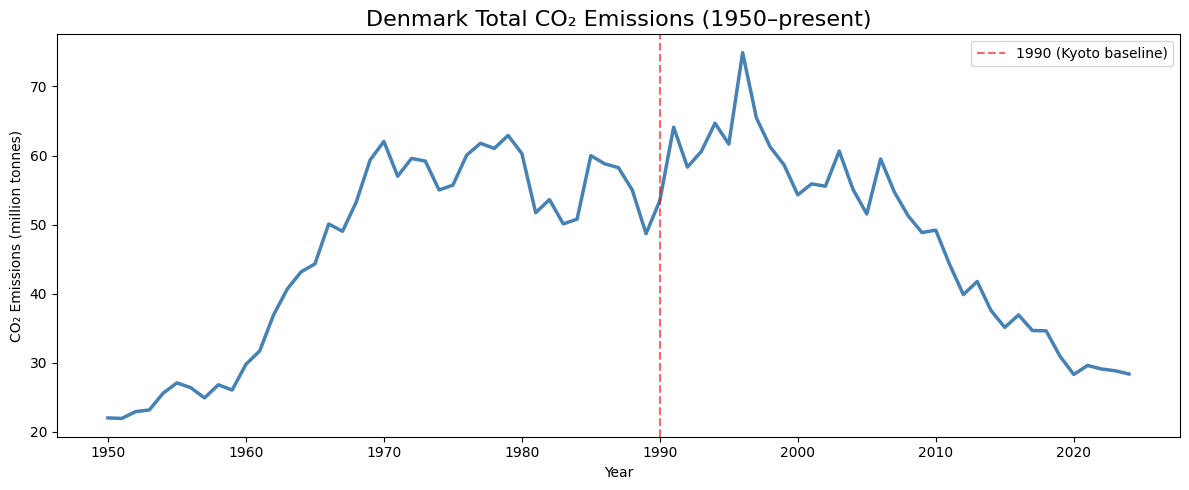

In [16]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=denmark, x="year", y="co2", color="steelblue", linewidth=2.5)

plt.title("Denmark Total CO₂ Emissions (1950–present)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (million tonnes)")
plt.axvline(x=1990, color="red", linestyle="--", alpha=0.6, label="1990 (Kyoto baseline)")
plt.legend()
plt.tight_layout()
plt.savefig("co2_total.png", dpi=150)
plt.show()

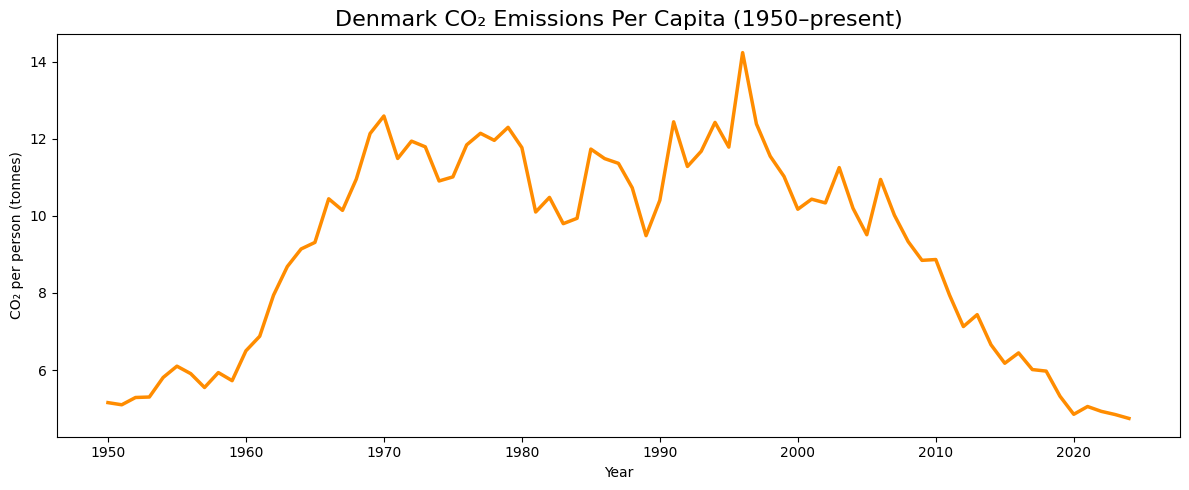

In [17]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=denmark, x="year", y="co2_per_capita", color="darkorange", linewidth=2.5)

plt.title("Denmark CO₂ Emissions Per Capita (1950–present)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("CO₂ per person (tonnes)")
plt.tight_layout()
plt.savefig("co2_per_capita.png", dpi=150)
plt.show()

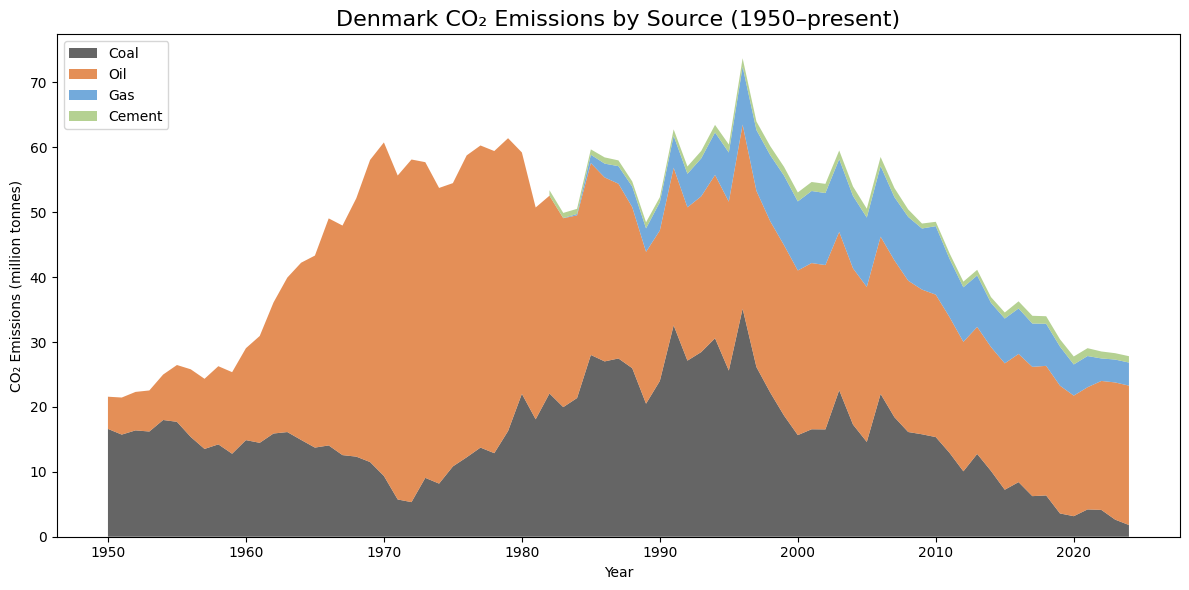

In [ ]:
sources = ["coal_co2", "oil_co2", "gas_co2", "cement_co2"]
labels  = ["Coal", "Oil", "Gas", "Cement"]
colors  = ["#4a4a4a", "#e07b39", "#5b9bd5", "#a8c97f"]

# Drop rows where any source column is null
source_data = denmark[["year"] + sources].dropna()

plt.figure(figsize=(12, 6))
plt.stackplot(
    source_data["year"],
    [source_data[s] for s in sources],
    labels=labels,
    colors=colors,
    alpha=0.85
)

plt.title("Denmark CO₂ Emissions by Source (1950–present)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (million tonnes)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("co2_by_source.png", dpi=150)
plt.show()

Key Findings: Denmark CO₂ Emissions Analysis
=============================================

1. PEAK EMISSIONS: Denmark's total CO₂ emissions peaked in the mid-1990s at around
   70 million tonnes and have declined significantly since — one of the stronger
   downward trends in Europe.

2. PER CAPITA PROGRESS: CO₂ per capita has dropped from a peak of ~12 tonnes per
   person in the 1970s to under 5 tonnes today, reflecting both efficiency gains
   and a major shift away from fossil fuels.

3. ENERGY MIX SHIFT: Coal was the dominant emissions source through the 1970s and
   1980s but has declined sharply since. Oil has remained the most persistent
   source, while gas has stayed relatively flat throughout.

4. POLICY IMPACT: The steepest decline in emissions coincides with Denmark's
   commitment to the Kyoto Protocol in 1990 and subsequent national climate
   targets, suggesting policy has played a meaningful role in driving the trend.

5. RENEWABLE TRANSITION: The consistent downward trend from the 1990s onward
   reflects Denmark's significant investment in wind energy, which now supplies
   a majority of the country's electricity.